105.0 332.2 2070.75 717.5
Intercept:  6.293157894736841
Slope:  1.9651127819548873
y = 6.29 + 1.97x


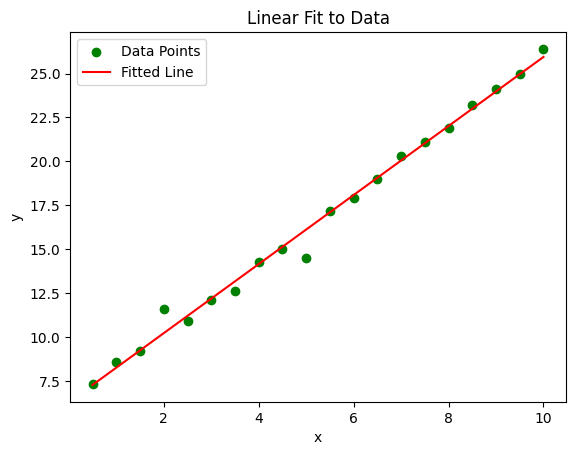

Derivative at x=2.0:  1.9651127819209078
Integral over the data range:  24.13596428571428
Coefficients of the fitted polynomial of degree 3: [1.40318245e-04 2.61335739e-02 1.67701520e+00 6.82945304e+00]
Coefficients of the fitted polynomial of degree 2: [0.02834359 1.66750513 6.83877193]
Coefficients of the fitted polynomial of degree 4: [-3.00358546e-03  6.32156129e-02 -4.06919087e-01  2.74704251e+00
  6.14553664e+00]


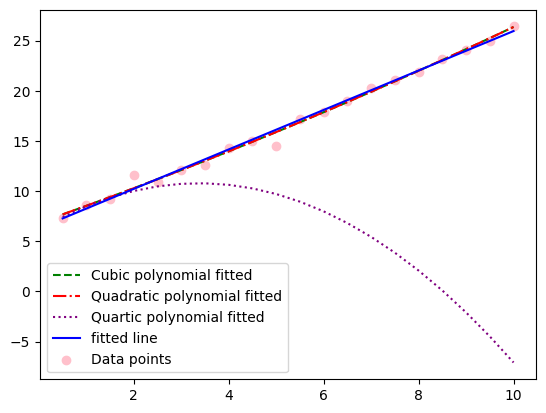

In [5]:

import csv
import matplotlib.pyplot as plt
import numpy as np
file = open("data.csv", "r")
content = csv.reader(file)
# print(content)

x = []
y = []

for row in content:
    x.append(float(row[0]))
    y.append(float(row[1]))

N = len(x) 

s_x = sum(i for i in x)
s_y = sum(i for i in y)
s_xy = sum(i * j for i, j in zip(x, y))
s_x2 = sum(i ** 2 for i in x)

print(s_x, s_y, s_xy, s_x2)

b = ((N * s_xy) - (s_x * s_y)) / (N * s_x2 - (s_x ** 2))
a = (s_y - b * s_x) / N

print("Intercept: ", a)
print("Slope: ", b)
print(f"y = {a:.2f} + {b:.2f}x")

y_fit = []

for i in x:
    y_fit.append(b * i + a)

plt.scatter(x, y, color="green", label="Data Points")
plt.plot(x, y_fit, color="red", label="Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Fit to Data")
plt.legend()
plt.show()

"""Second Part: Students would estimate the differentiation at a point and integration 
in the data range using the fitted curve. Finally generalize the program to fit nth order polynomial with
the suitable plots for visulization. 
"""
def derivative_at_point(x, y_fit, point):
    # Using central difference method for numerical differentiation
    h = 1e-5  # step size
    f_x_plus_h = a + b * (point + h)
    f_x_minus_h = a + b * (point - h)
    derivative = (f_x_plus_h - f_x_minus_h) / (2 * h)
    return derivative
print("Derivative at x=2.0: ", derivative_at_point(x, y_fit, 2.0))
def integral(x,y_fit):
    # Using trapezoidal rule for numerical integration
    h=(max(x)-min(x))/N
    integral_val=(h/2)*(y_fit[0]+y_fit[N-1])
    for j in (1,N-1):
        integral_val+=h*y_fit[j]
    return integral_val
print("Integral over the data range: ", integral(x, y_fit))
def polynomial_fit(x, y, degree):
    coefficients = np.polyfit(x, y, degree)
    polynomial = np.poly1d(coefficients)
    return polynomial
degree1 = 3  #fitting a cubic polynomial
polynomial = polynomial_fit(x, y, degree1)
print(f"Coefficients of the fitted polynomial of degree {degree1}: {polynomial.coefficients}")
cube_y_fit=[]
for i in x:
    pol=0
    for j in range(0,degree1+1):
        pol+=(polynomial[j])*(i**j) 
    cube_y_fit.append(pol)

degree2=2 #fitting a quadratic polynomial
polynomial_1 = polynomial_fit(x, y, degree2)
print(f"Coefficients of the fitted polynomial of degree {degree2}: {polynomial_1.coefficients}")
quad_y_fit=[]
for i in x:
    pol1=0
    for j in range(0,degree2+1):
        pol1+=(polynomial_1[j])*(i**j) 
    quad_y_fit.append(pol1)
degree3=4 #fitting a polynomial of degree 4
polynomial_2 = polynomial_fit(x, y, degree3)
print(f"Coefficients of the fitted polynomial of degree {degree3}: {polynomial_2.coefficients}")
quart_y_fit=[]
for i in x:
    pol2=0
    for j in range(0,degree2+1):
        pol2+=(polynomial_2[j])*(i**j) 
    quart_y_fit.append(pol2)
plt.plot(x,cube_y_fit,color="g",label="Cubic polynomial fitted",linestyle="dashed")
plt.plot(x,quad_y_fit,color="r",label="Quadratic polynomial fitted",linestyle="dashdot")
plt.plot(x,quart_y_fit,color="purple",label="Quartic polynomial fitted",linestyle="dotted")
plt.plot(x,y_fit,color="b",label="fitted line",linestyle="solid")
plt.scatter(x,y,color='pink',label="Data points")
plt.legend()
plt.show()
# Instructions: Students are advised to learn the theory for the polynomial fitting and do all the required derivations in their notes.